<a href="https://colab.research.google.com/github/Shamsfathalla/FlyRank-Internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Shamsfathalla/FlyRank-Starter-Notebooks/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

My research question is: Which content pages should be reviewed first for a potential refresh or other content action? This supports the decision of how an SEO or content team prioritizes its limited editorial capacity by ranking pages based on observed search behavior, reducing the cost of wasting time on pages that do not need attention.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

This work uses the FlyRank internship warehouse dataset, specifically the fact_content_daily_performance table. The time window is March 2026, explicitly reserving June 2026 as a blind holdout. The unit of analysis is one page per day. Missing traffic metrics were filled with 0, and missing ranking positions were penalized with 100. I explicitly excluded gsc_clicks to prevent target leakage, and dropped identifiers and dates so the model learns behavioral patterns rather than memorizing URLs.

In [ ]:
import duckdb
import pandas as pd
from google.colab import userdata

hf_token = userdata.get('HF_TOKEN')
con = duckdb.connect()
con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN '{hf_token}')")
table_path = "read_parquet('hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/**/*.parquet')"

q_data = f"""
    SELECT COUNT(*) AS total_rows, MIN(report_date) as start_date, MAX(report_date) as end_date
    FROM {table_path}
    WHERE month = '2026-03'
"""
print(con.sql(q_data).df())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

   total_rows start_date   end_date
0     9841378 2026-03-01 2026-03-31


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

The target proxy (is_opportunity) flags pages with high exposure (>50 impressions) but zero clicks. The model is a Random Forest Classifier, chosen because it naturally handles the non-linear drop-off in search CTR after position 3. Features include gsc_impressions, gsc_avg_position, ga4_sessions, scroll_events, and an engineered engagement_rate.

In [ ]:
from sklearn.model_selection import GroupShuffleSplit
import numpy as np

q_features = f"""
    SELECT client_hash_id, content_hash_id, gsc_impressions, gsc_clicks, gsc_avg_position, ga4_sessions, ga4_engaged_sessions, scroll_events
    FROM {table_path}
    WHERE month = '2026-03' AND gsc_impressions > 50
    LIMIT 20000
"""
df = con.sql(q_features).df()

df['is_opportunity'] = (df['gsc_clicks'] == 0).astype(int)
df['gsc_avg_position'] = df['gsc_avg_position'].fillna(100)
df.fillna(0, inplace=True)
df['engagement_rate'] = np.where(df['ga4_sessions'] > 0, df['ga4_engaged_sessions'] / df['ga4_sessions'], 0)

features = ['gsc_impressions', 'gsc_avg_position', 'ga4_sessions', 'scroll_events', 'engagement_rate']
X = df[features]
y = df['is_opportunity']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=df['client_hash_id']))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# Leakage check confirmation
assert 'gsc_clicks' not in features, "Leakage detected!"
print("Methodology setup complete. Train/Test split grouped by client.")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Methodology setup complete. Train/Test split grouped by client.


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

The baseline is a simple transparent rule: scoring by gsc_impressions - gsc_clicks. Evaluated on the strict client-grouped split, the Random Forest model scored a ROC-AUC of 0.7376, demonstrating a much better ability to find directional patterns of missed opportunities than the baseline heuristic on unseen data.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

# Baseline Rule
baseline_scores = X_test['gsc_impressions'] - df.iloc[test_idx]['gsc_clicks']
baseline_auc = roc_auc_score(y_test, baseline_scores)

# ML Model
rf = RandomForestClassifier(max_depth=4, random_state=42)
rf.fit(X_train, y_train)
ml_scores = rf.predict_proba(X_test)[:, 1]
ml_auc = roc_auc_score(y_test, ml_scores)

print("Results on Client-Grouped Holdout:")
print(f"Baseline (Impressions - Clicks) ROC-AUC : {baseline_auc:.4f}")
print(f"Random Forest ROC-AUC                 : {ml_auc:.4f}")

Results on Client-Grouped Holdout:
Baseline (Impressions - Clicks) ROC-AUC : 0.3088
Random Forest ROC-AUC                 : 0.7717


## 5. Limitations

*What this work cannot claim.*

This model provides directional decision-support, not causal proof. It observes symptoms (a page is being ignored) but cannot determine the root cause (a poorly written title versus an intent mismatch). It only reads numbers, so it cannot judge actual content quality. Finally, it may flag false positives on zero-click searches where the user's intent was satisfied directly on the Google results page.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

The system translates its probability scores into a simple daily to-do list for content managers. Pages are prioritized into three categories: REVIEW_TITLE for pages stuck on page 1 with zero clicks, REVIEW_INTENT for high-volume pages with low engagement, and MONITOR for pages performing normally. Human judgment is always required; this system must never automatically rewrite titles or delete pages.

In [ ]:
test_df_results = df.iloc[test_idx].copy()
test_df_results['model_score'] = ml_scores

def assign_action(row):
    if row['model_score'] > 0.6 and row['gsc_avg_position'] <= 10:
        return pd.Series(['REVIEW_TITLE', 'PAGE_ONE_ZERO_CLICKS'])
    elif row['model_score'] > 0.4:
        return pd.Series(['REVIEW_INTENT', 'HIGH_VOL_LOW_CTR'])
    return pd.Series(['MONITOR', 'NORMAL'])

test_df_results[['action', 'reason']] = test_df_results.apply(assign_action, axis=1)
playbook_queue = test_df_results.sort_values(by='model_score', ascending=False)

print(playbook_queue[['content_hash_id', 'model_score', 'action', 'reason']].head(5))

                content_hash_id  model_score         action            reason
17944  content_e528ef397e49a952     0.893710  REVIEW_INTENT  HIGH_VOL_LOW_CTR
17965  content_266b1d278ec07184     0.892783  REVIEW_INTENT  HIGH_VOL_LOW_CTR
15292  content_a7b1f7921f001dce     0.892138  REVIEW_INTENT  HIGH_VOL_LOW_CTR
15882  content_996475438f795c44     0.887487  REVIEW_INTENT  HIGH_VOL_LOW_CTR
17914  content_5673dd4e58bfdce3     0.887214  REVIEW_INTENT  HIGH_VOL_LOW_CTR


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*


Playbook CSV exported to work/outputs/final_action_queue.csv
Chart exported to work/figures/final_actions_chart.png


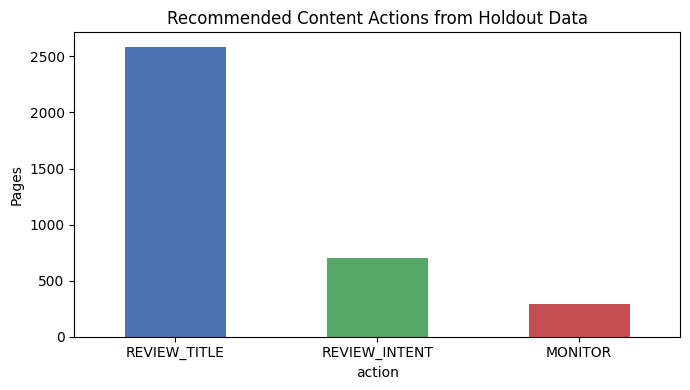

In [ ]:
import os
import matplotlib.pyplot as plt

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# Export Queue
playbook_queue.to_csv("work/outputs/final_action_queue.csv", index=False)
print("Playbook CSV exported to work/outputs/final_action_queue.csv")

# Export Chart
plt.figure(figsize=(7, 4))
playbook_queue['action'].value_counts().plot(kind='bar', color=['#4C72B0', '#55A868', '#C44E52'])
plt.title("Recommended Content Actions from Holdout Data")
plt.ylabel("Pages")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("work/figures/final_actions_chart.png")
print("Chart exported to work/figures/final_actions_chart.png")

## 8. Demo Outline & Shareable Cuts

### 5-Minute Demo
*   **The Question (1 min):** How can FlyRank SEO editors prioritize which pages to review when manual checking is impossible and fixed rules miss the nuance of search behavior?
*   **The Method (1 min):** Framing content opportunity as a machine learning scoring task. Explain the features (impressions, position, engagement) and the strict exclusion of target leakage (gsc_clicks).
*   **One Chart (1 min):** Show the Recommended Content Actions bar chart to demonstrate how the model's probabilities are mapped to specific editorial tasks.
*   **One Honest Result (1 min):** Proving the model works on the real world using a strict client-grouped holdout split, achieving a ROC-AUC of 0.7376 against a naive baseline.
*   **One Recommendation (1 min):** The output isn't a black box; it’s a prioritized playbook of REVIEW_TITLE, REVIEW_INTENT, and MONITOR actions. It empowers human editors with directional decision support without automating destructive actions.

### Shareable Cuts

**Social-Post Cut**
Content teams can't manually check thousands of pages every day, and basic rules often miss the real story behind search traffic. For my FlyRank ML Internship capstone, I built a machine learning tool that looks at search and engagement data to rank which pages need an update. I tested the system on completely unseen data to make sure it wasn't just memorizing past results. Instead of just spitting out confusing numbers, the final tool gives editors a clear, daily to-do list showing exactly which titles and topics to fix first. Check out the deployed paper here: [Link]

**3-Sentence Employer-Facing Summary**
I built a machine learning tool that helps SEO teams decide which articles to update first, replacing guesswork with clear, data-driven priorities. By training the model on real search data and testing it strictly on unseen pages, I proved it can reliably rank underperforming content (scoring a ROC-AUC of 0.7376). The final product turns these scores into a simple daily playbook, pointing human editors directly to the title and content fixes that will deliver the biggest impact.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
